In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import re
from rapidfuzz import fuzz

In [2]:
def normalize_text(s):
    """Basic text normalization: strip, lowercase, remove articles, collapse whitespace, strip trailing punctuation."""
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    # remove leading articles
    s = re.sub(r'^(a|an|the)\s+', '', s)
    # collapse multiple spaces
    s = re.sub(r'\s+', ' ', s)
    # strip trailing punctuation
    s = re.sub(r'[.,;:!?]+$', '', s)
    return s.strip()


def normalize_and_dedup(series, fuzzy_threshold=85, max_unique_for_fuzzy=500):
    """Normalize a pandas Series and fuzzy-dedup near-duplicate values."""
    normed = series.map(normalize_text)
    unique_vals = normed.dropna().unique()
    if len(unique_vals) > max_unique_for_fuzzy:
        print(f'  Skipping fuzzy dedup ({len(unique_vals)} unique > {max_unique_for_fuzzy})')
        return normed
    freq = normed.value_counts()
    sorted_vals = freq.index.tolist()
    canonical_map = {}
    canonicals = []
    for val in sorted_vals:
        if pd.isna(val):
            continue
        matched = False
        for canon in canonicals:
            if fuzz.ratio(val, canon) >= fuzzy_threshold:
                canonical_map[val] = canon
                matched = True
                break
        if not matched:
            canonicals.append(val)
            canonical_map[val] = val
    merged_count = sum(1 for k, v in canonical_map.items() if k != v)
    if merged_count > 0:
        print(f'  Fuzzy dedup merged {merged_count} values into existing canonical forms')
    return normed.map(lambda x: canonical_map.get(x, x))

In [3]:
religious_texts_reasoning = pd.read_parquet('/share/pierson/matt/UAIR/outputs/2026-02-11/15-40-07/ci_extraction_religious/outputs/ci_reasoning/reasoning.parquet')
religious_text_flows = pd.read_parquet('/share/pierson/matt/UAIR/outputs/2026-02-11/15-40-07/ci_extraction_religious/outputs/ci_extraction/ci_flows.parquet') 

In [4]:
religious_text_flows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18742 entries, 0 to 18741
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gutenberg_id               18742 non-null  object 
 1   chunk_id                   18742 non-null  int64  
 2   article_text               18742 non-null  object 
 3   chunk_size                 18742 non-null  int64  
 4   article_path               18742 non-null  object 
 5   country                    18742 non-null  object 
 6   year                       18742 non-null  object 
 7   article_id                 18742 non-null  object 
 8   ci_reasoning_json          18742 non-null  object 
 9   ci_reasoning_parse_error   0 non-null      object 
 10  generated_text             18742 non-null  object 
 11  has_information_exchange   18742 non-null  bool   
 12  ci_flow_count              18742 non-null  int64  
 13  ci_flow_index              18742 non-null  int

In [5]:
"""
  - 30    # The Bible, King James Version (Complete) -- contains Leviticus, Deuteronomy, Proverbs, etc.
  - 3434  # The Koran (Al-Qur'an), trans. J.M. Rodwell -- prescriptive throughout
  - 8547  # Pirke Avot (Ethics of the Fathers) -- Jewish ethical maxims and teachings on conduct
  - 2017  # Dhammapada (Buddhist canonical text), trans. F. Max Müller -- ethical verses/precepts
  - 2388  # Bhagavad-Gita (The Song Celestial), trans. Sir Edwin Arnold -- dharmic duties and conduct
  - 216   # Tao Te Ching (The Tao Teh King), trans. James Legge -- prescriptive philosophy
  - 3330  # The Analects of Confucius, trans. James Legge -- ethical teachings and social norms
  - 17    # The Book of Mormon -- contains prescriptive moral/theological content
"""

ids_to_name = pd.DataFrame({
    'gutenberg_id': ["30", "3434", "8547", "2017", "2388", "216", "3330", "17"],
    'name': [
        'The Bible, King James Version (Complete)',
        'The Koran (Al-Qur\'an), trans. J.M. Rodwell',
        'Pirke Avot (Ethics of the Fathers)',
        'Dhammapada (Buddhist canonical text), trans. F. Max Müller',
        'Bhagavad-Gita (The Song Celestial), trans. Sir Edwin Arnold',
        'Tao Te Ching (The Tao Teh King), trans. James Legge',
        'The Analects of Confucius, trans. James Legge',
        'The Book of Mormon',
    ],
})  

In [6]:
religious_text_flows = religious_text_flows.merge(ids_to_name, on='gutenberg_id', how='left')

In [7]:
religious_texts_by_id = religious_text_flows.groupby('gutenberg_id')

In [8]:
cols_to_normalize = [
    'ci_context', 'ci_flow_context', 'ci_subject', 'ci_sender',
    'ci_recipient', 'ci_information_type', 'ci_transmission_principle',
    'ci_norms_invoked', 'ci_norm_source',
]

for col in cols_to_normalize:
    print(f'Normalizing {col} ...')
    religious_text_flows[col] = normalize_and_dedup(religious_text_flows[col])
    print()

Normalizing ci_context ...
  Skipping fuzzy dedup (788 unique > 500)

Normalizing ci_flow_context ...
  Fuzzy dedup merged 109 values into existing canonical forms

Normalizing ci_subject ...
  Skipping fuzzy dedup (2297 unique > 500)

Normalizing ci_sender ...


  Skipping fuzzy dedup (3272 unique > 500)

Normalizing ci_recipient ...
  Skipping fuzzy dedup (3996 unique > 500)

Normalizing ci_information_type ...
  Skipping fuzzy dedup (8143 unique > 500)

Normalizing ci_transmission_principle ...
  Skipping fuzzy dedup (611 unique > 500)

Normalizing ci_norms_invoked ...
  Skipping fuzzy dedup (17820 unique > 500)

Normalizing ci_norm_source ...



In [9]:
# Unique religious texts (by gutenberg_id)
names = religious_text_flows['name'].unique().tolist()
print(f'Number of unique religious texts: {len(names)}')
flows_per_text = religious_text_flows.groupby('name').size().sort_values(ascending=False)
flows_per_text

Number of unique religious texts: 8


name
The Bible, King James Version (Complete)                       11214
The Book of Mormon                                              3653
The Koran (Al-Qur'an), trans. J.M. Rodwell                      2684
The Analects of Confucius, trans. James Legge                    559
Pirke Avot (Ethics of the Fathers)                               274
Bhagavad-Gita (The Song Celestial), trans. Sir Edwin Arnold      248
Tao Te Ching (The Tao Teh King), trans. James Legge               74
Dhammapada (Buddhist canonical text), trans. F. Max Müller        36
dtype: int64

In [10]:
# Union of ci_context across all religious texts; counts per gutenberg_id
ci_contexts_union = religious_text_flows['ci_context'].dropna().unique()

counts_by_id = {}
for gid in names:
    sub = religious_text_flows.loc[religious_text_flows['name'] == gid, 'ci_context']
    counts_by_id[gid] = sub.value_counts().reindex(ci_contexts_union, fill_value=0).values

ci_context_counts = pd.DataFrame({
    'ci_context': ci_contexts_union,
    **{gid: counts_by_id[gid] for gid in names},
})
ci_context_counts['sum_counts'] = ci_context_counts[[c for c in ci_context_counts.columns if c != 'ci_context']].sum(axis=1)
ci_context_counts = ci_context_counts.sort_values(by='sum_counts', ascending=False)
ci_context_counts.head(15)

,ci_context,"The Bible, King James Version (Complete)","The Koran (Al-Qur'an), trans. J.M. Rodwell",Pirke Avot (Ethics of the Fathers),"Dhammapada (Buddhist canonical text), trans. F. Max Müller","Bhagavad-Gita (The Song Celestial), trans. Sir Edwin Arnold","Tao Te Ching (The Tao Teh King), trans. James Legge","The Analects of Confucius, trans. James Legge",The Book of Mormon,sum_counts
0,religious,4697,1048,70,4,53,0,2,1297,7171
26,religion,1156,923,55,5,48,0,0,827,3014
7,governance,1162,47,1,0,0,21,102,364,1697
20,military,370,17,0,0,15,1,0,289,692
3,family,418,57,0,0,0,0,20,133,628
28,state/political,449,78,0,0,0,3,8,81,619
32,legal,451,64,4,0,0,0,2,79,600
343,education,13,23,37,1,5,0,252,3,334
29,social etiquette,161,27,8,1,1,1,40,29,268
17,courtship,209,10,1,0,0,0,11,14,245


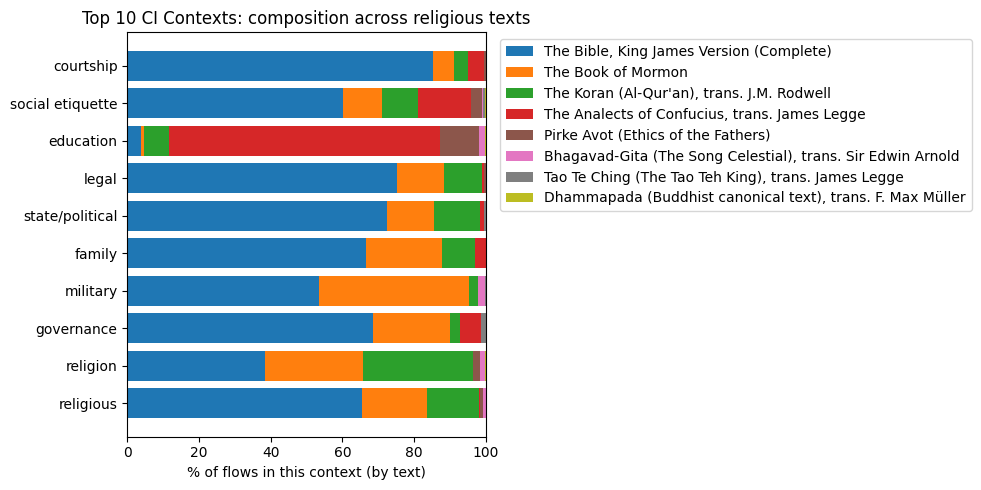

In [11]:
# Top 10 CI contexts: stacked bar by religious text (row = 100%, composition of who contributes)
top10_contexts = ci_context_counts.head(10)
n_texts_legend = min(8, len(names))
ids_sorted_by_flows = flows_per_text.index.tolist()
ids_in_legend = ids_sorted_by_flows[:n_texts_legend]
ids_other = ids_sorted_by_flows[n_texts_legend:]

# For each context (row), normalize counts so row sums to 100%
id_cols = [c for c in top10_contexts.columns if c not in ('ci_context', 'sum_counts')]
row_sums = top10_contexts[id_cols].sum(axis=1).replace(0, np.nan)
pct = top10_contexts[id_cols].div(row_sums, axis=0).fillna(0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(top10_contexts))
left = np.zeros(len(top10_contexts))
colors = plt.cm.tab10(np.linspace(0, 1, n_texts_legend + 1))

for i, gid in enumerate(ids_in_legend):
    vals = pct[gid].values
    ax.barh(y_pos, vals, left=left, label=gid, color=colors[i])
    left += vals

if ids_other:
    other_vals = pct[ids_other].sum(axis=1).values
    ax.barh(y_pos, other_vals, left=left, label='Other', color=colors[-1])

ax.set_yticks(y_pos)
ax.set_yticklabels(top10_contexts['ci_context'])
ax.set_xlabel('% of flows in this context (by text)')
ax.set_title('Top 10 CI Contexts: composition across religious texts')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

In [12]:
# Same for ci_flow_context: union and counts per gutenberg_id
ci_flow_contexts_union = religious_text_flows['ci_flow_context'].dropna().unique()

counts_flow_by_id = {}
for gid in names:
    sub = religious_text_flows.loc[religious_text_flows['name'] == gid, 'ci_flow_context']
    counts_flow_by_id[gid] = sub.value_counts().reindex(ci_flow_contexts_union, fill_value=0).values

ci_flow_context_counts = pd.DataFrame({
    'ci_flow_context': ci_flow_contexts_union,
    **{gid: counts_flow_by_id[gid] for gid in names},
})
ci_flow_context_counts['sum_counts'] = ci_flow_context_counts[[c for c in ci_flow_context_counts.columns if c != 'ci_flow_context']].sum(axis=1)
ci_flow_context_counts = ci_flow_context_counts.sort_values(by='sum_counts', ascending=False)
ci_flow_context_counts.head(15)

,ci_flow_context,"The Bible, King James Version (Complete)","The Koran (Al-Qur'an), trans. J.M. Rodwell",Pirke Avot (Ethics of the Fathers),"Dhammapada (Buddhist canonical text), trans. F. Max Müller","Bhagavad-Gita (The Song Celestial), trans. Sir Edwin Arnold","Tao Te Ching (The Tao Teh King), trans. James Legge","The Analects of Confucius, trans. James Legge",The Book of Mormon,sum_counts
1,religious,5618,1788,108,13,79,0,4,1939,9549
7,governance,1091,49,0,0,0,29,127,409,1705
11,religion,378,309,21,5,48,1,0,177,939
4,social etiquette,553,81,17,1,2,1,144,107,906
3,family,498,77,0,0,0,0,17,173,765
10,military,373,32,0,0,22,2,1,327,757
19,legal,296,45,5,0,0,1,4,83,434
172,education,10,20,28,2,10,0,205,3,278
43,state/political,218,17,1,0,0,7,7,8,258
5,legal/religious,190,19,2,0,0,0,0,19,230


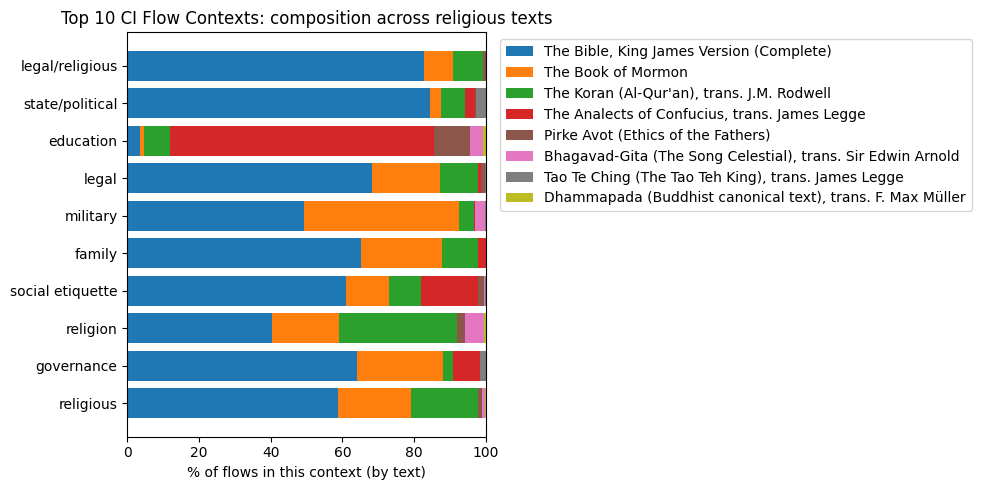

In [13]:
# Top 10 CI flow contexts: stacked bar by religious text
top10_flow = ci_flow_context_counts.head(10)
id_cols_f = [c for c in top10_flow.columns if c not in ('ci_flow_context', 'sum_counts')]
row_sums_f = top10_flow[id_cols_f].sum(axis=1).replace(0, np.nan)
pct_f = top10_flow[id_cols_f].div(row_sums_f, axis=0).fillna(0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(top10_flow))
left = np.zeros(len(top10_flow))
colors = plt.cm.tab10(np.linspace(0, 1, n_texts_legend + 1))

for i, gid in enumerate(ids_in_legend):
    vals = pct_f[gid].values
    ax.barh(y_pos, vals, left=left, label=gid, color=colors[i])
    left += vals
if ids_other:
    other_vals = pct_f[ids_other].sum(axis=1).values
    ax.barh(y_pos, other_vals, left=left, label='Other', color=colors[-1])

ax.set_yticks(y_pos)
ax.set_yticklabels(top10_flow['ci_flow_context'])
ax.set_xlabel('% of flows in this context (by text)')
ax.set_title('Top 10 CI Flow Contexts: composition across religious texts')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

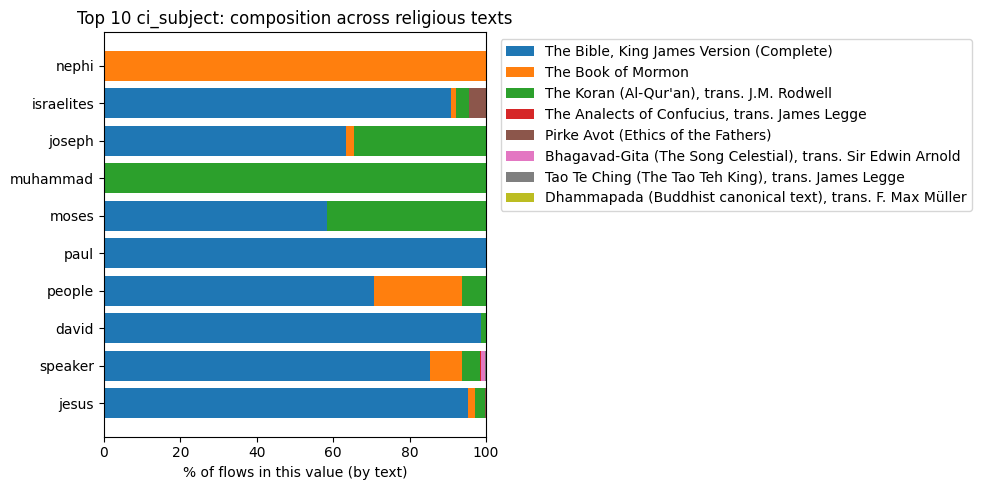

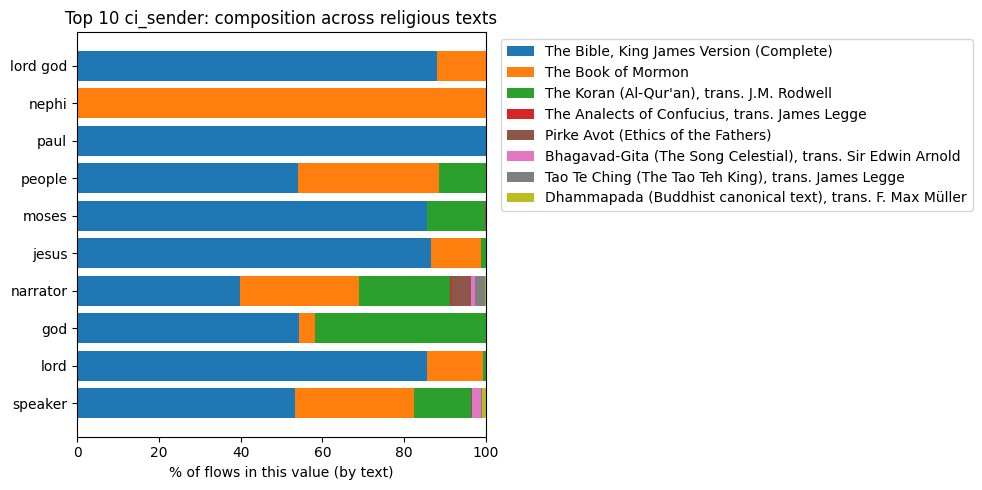

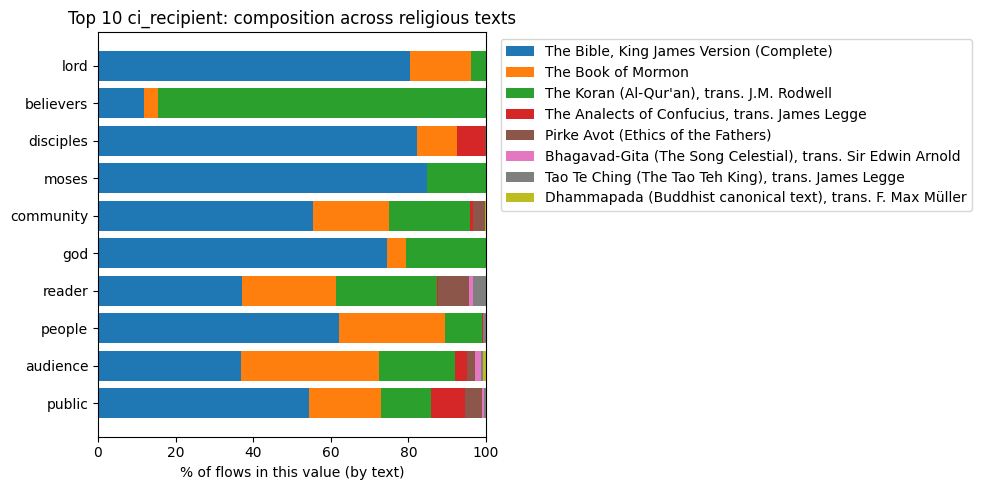

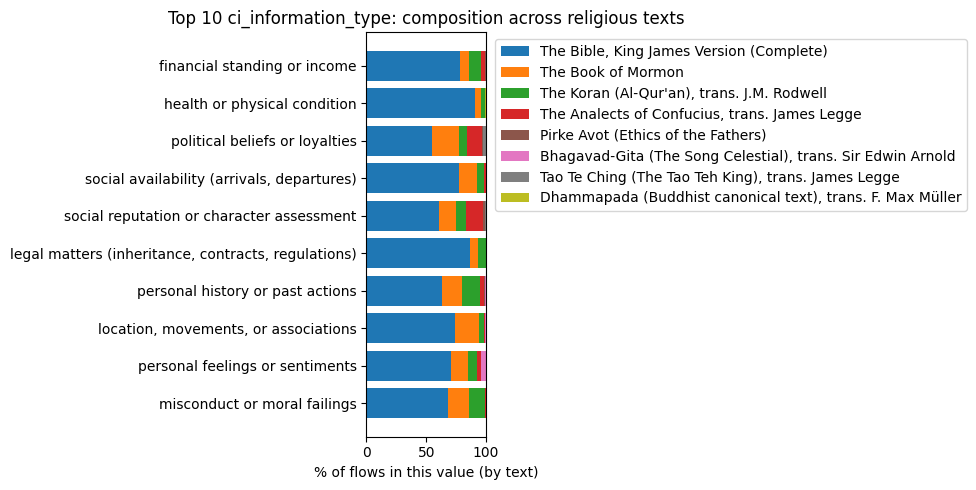

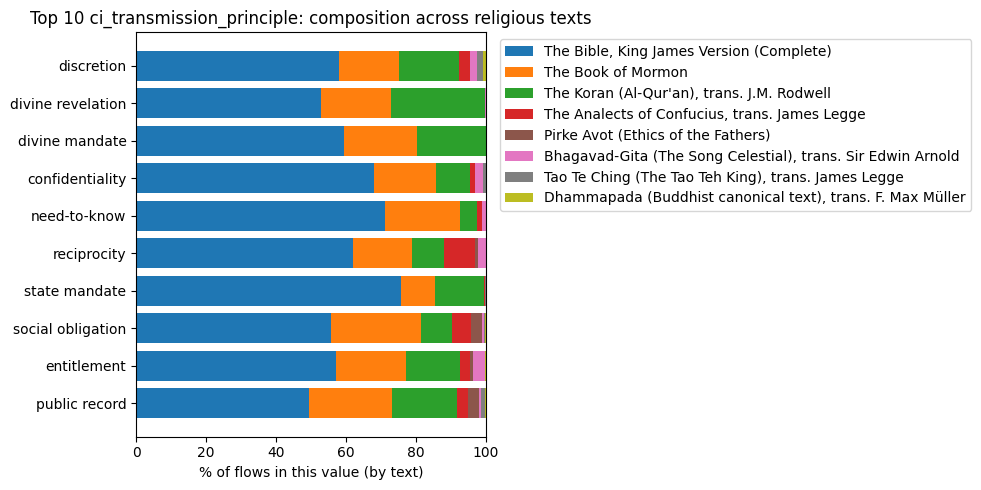

/tmp/ipykernel_3499219/949142582.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


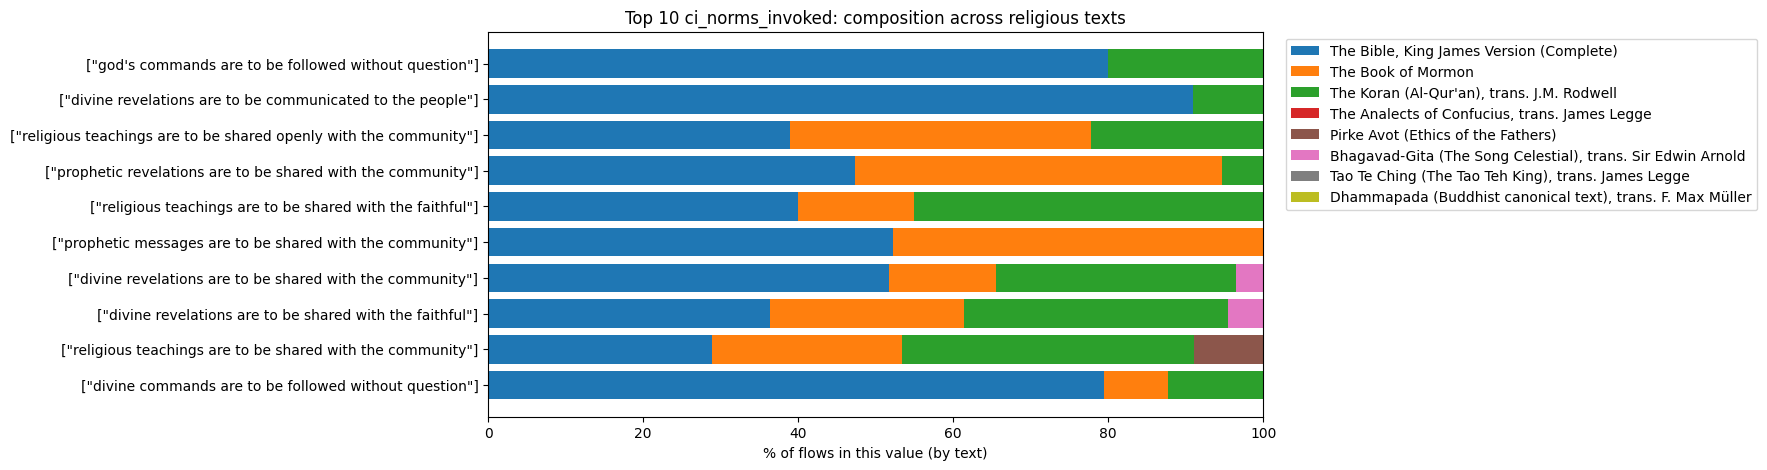

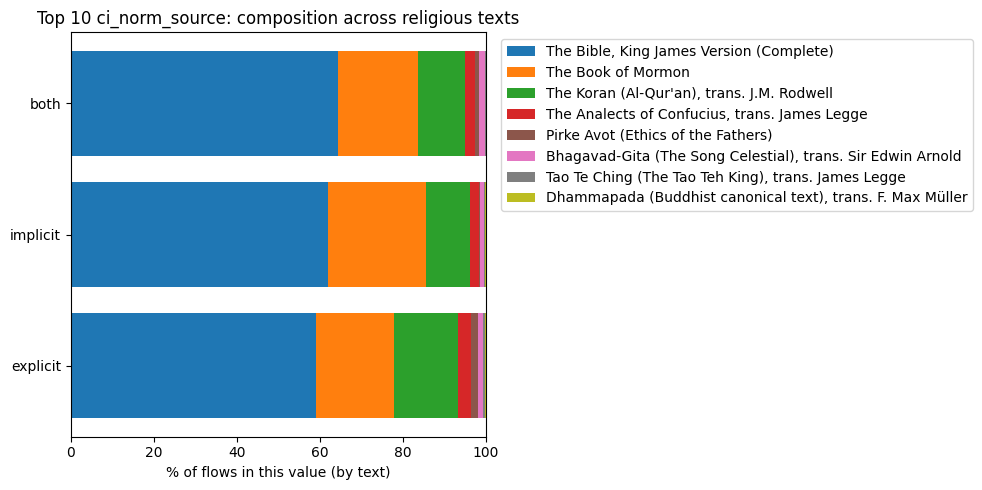

In [14]:
columns_to_plot = [
    'ci_subject', 'ci_sender', 'ci_recipient',
    'ci_information_type', 'ci_transmission_principle',
    'ci_norms_invoked', 'ci_norm_source',
]

for col in columns_to_plot:
    union_vals = religious_text_flows[col].dropna().unique()
    counts_by_id = {}
    for gid in names:
        sub = religious_text_flows.loc[religious_text_flows['name'] == gid, col]
        counts_by_id[gid] = sub.value_counts().reindex(union_vals, fill_value=0).values

    df = pd.DataFrame({
        col: union_vals,
        **{gid: counts_by_id[gid] for gid in names},
    })
    df['sum_counts'] = df[[c for c in df.columns if c != col]].sum(axis=1)
    df = df.sort_values(by='sum_counts', ascending=False).head(10)

    id_cols = [c for c in df.columns if c not in (col, 'sum_counts')]
    row_sums = df[id_cols].sum(axis=1).replace(0, np.nan)
    pct = df[id_cols].div(row_sums, axis=0).fillna(0) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = np.arange(len(df))
    left = np.zeros(len(df))
    colors = plt.cm.tab10(np.linspace(0, 1, n_texts_legend + 1))

    for i, gid in enumerate(ids_in_legend):
        vals = pct[gid].values
        ax.barh(y_pos, vals, left=left, label=gid, color=colors[i])
        left += vals
    if ids_other:
        other_vals = pct[ids_other].sum(axis=1).values
        ax.barh(y_pos, other_vals, left=left, label='Other', color=colors[-1])

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df[col])
    ax.set_xlabel('% of flows in this value (by text)')
    ax.set_title(f'Top 10 {col}: composition across religious texts')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()

In [15]:
bible_subset_of_interest = religious_text_flows[
    (religious_text_flows['name'] == 'The Bible, King James Version (Complete)') & 
    (religious_text_flows['ci_context'] == 'governance')
]

# define a templated function that prints out a pretty english-language description of the ci_flow, using ci_subject, ci_sender, ci_recipient, ci_information_type, ci_transmission_principle, ci_norms_invoked, ci_norm_source
def generate_ci_flow(ci_flow):
    return f"CI Flow: {ci_flow['ci_sender']} sends {ci_flow['ci_information_type']} about {ci_flow['ci_subject']} to {ci_flow['ci_recipient']} based on {ci_flow['ci_transmission_principle']}, classified as {ci_flow['ci_appropriateness']} based on the {ci_flow['ci_norm_source']} norm in the {ci_flow['ci_context']} context of {ci_flow['ci_norms_invoked']}"

# apply the function to the ci_flow column
bible_subset_of_interest['ci_flow'] = bible_subset_of_interest.apply(generate_ci_flow, axis=1)



/tmp/ipykernel_3499219/4156442766.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bible_subset_of_interest['ci_flow'] = bible_subset_of_interest.apply(generate_ci_flow, axis=1)


In [16]:
religious_text_flows[['ci_subject', 'ci_sender', 'ci_recipient', 'ci_information_type', 'ci_transmission_principle', 'ci_norms_invoked', 'ci_norm_source']].isna().sum() / len(religious_text_flows)

ci_subject                   0.587611
ci_sender                    0.000587
ci_recipient                 0.000587
ci_information_type          0.000587
ci_transmission_principle    0.000587
ci_norms_invoked             0.000587
ci_norm_source               0.000587
dtype: float64

In [17]:
ethics_of_our_fathers_subset_of_interest = religious_text_flows[
    (religious_text_flows['name'] == 'Pirke Avot (Ethics of the Fathers)')
]

ethics_of_our_fathers_subset_of_interest['ci_flow'] = ethics_of_our_fathers_subset_of_interest.apply(generate_ci_flow, axis=1)


/tmp/ipykernel_3499219/1588212571.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ethics_of_our_fathers_subset_of_interest['ci_flow'] = ethics_of_our_fathers_subset_of_interest.apply(generate_ci_flow, axis=1)


In [22]:
ethics_of_our_fathers_subset_of_interest[['gutenberg_id', 'chunk_id','ci_flow','article_text']].to_csv('ethics_of_our_fathers_ci_flows.csv', index=False)

In [19]:
ethics_of_our_fathers_subset_of_interest

,gutenberg_id,chunk_id,article_text,chunk_size,article_path,country,year,article_id,ci_reasoning_json,ci_reasoning_parse_error,...,ci_information_type,ci_transmission_principle,ci_context,ci_appropriateness,ci_norms_invoked,ci_norm_source,ci_confidence,extraction_error,name,ci_flow
13898,8547,2,It is the humble hope of the editor that this ...,1939,,,,,"{""flows"": [{""original_text_snippet"": ""It is th...",None,...,purpose and intended impact of the book,public record,education,appropriate,"[""the editor is expected to communicate the pu...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),CI Flow: editor sends purpose and intended imp...
13899,8547,2,It is the humble hope of the editor that this ...,1939,,,,,"{""flows"": [{""original_text_snippet"": ""It is th...",None,...,historical and cultural context,public record,education,appropriate,"[""educational content should be clear and info...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),CI Flow: author or narrator sends historical a...
13900,8547,2,It is the humble hope of the editor that this ...,1939,,,,,"{""flows"": [{""original_text_snippet"": ""It is th...",None,...,general news,public record,scholarship,appropriate,"[""scholars are expected to provide comprehensi...",explicit,0.90,None,Pirke Avot (Ethics of the Fathers),CI Flow: taylor sends general news about None ...
13901,8547,3,"(3) See _Sun and Shield_, p. 321 _et passim_. ...",1837,,,,,"{""flows"": [{""original_text_snippet"": ""Samuel d...",None,...,interpretation of religious text,public record,religious,appropriate,"[""scholarly interpretations of religious texts...",explicit,0.95,None,Pirke Avot (Ethics of the Fathers),CI Flow: samuel de uceda sends interpretation ...
13902,8547,3,"(3) See _Sun and Shield_, p. 321 _et passim_. ...",1837,,,,,"{""flows"": [{""original_text_snippet"": ""Samuel d...",None,...,ethical and moral teachings and doctrines,public record,education,appropriate,"[""scholarly discourse is expected to be shared...",explicit,0.90,None,Pirke Avot (Ethics of the Fathers),CI Flow: samuel de uceda sends ethical and mor...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14167,8547,102,"10. Five possessions the Holy One, blessed be ...",1981,,,,,"{""flows"": [{""original_text_snippet"": ""Five pos...",None,...,scriptural references,public record,religious,appropriate,"[""scriptural references are considered public ...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),CI Flow: narrator sends scriptural references ...
14168,8547,103,"Rabbi Chanania, the son of Akashia, said, ""The...",1970,,,,,"{""flows"": [{""original_text_snippet"": ""Rabbi Ch...",None,...,religious teaching,entitlement,religion,appropriate,"[""religious authorities are entitled to share ...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),"CI Flow: rabbi chanania, the son of akashia se..."
14169,8547,107,"Consider three things,\r\n 42 the day of thy...",1828,,,,,"{""flows"": [{""original_text_snippet"": ""R. Chani...",None,...,religious instruction,social obligation,religion,appropriate,"[""religious authorities are expected to share ...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),CI Flow: r. chanina sends religious instructio...
14170,8547,107,"Consider three things,\r\n 42 the day of thy...",1828,,,,,"{""flows"": [{""original_text_snippet"": ""R. Chani...",None,...,religious teachings and moral guidance,public record,religion,appropriate,"[""religious teachings are to be shared publicl...",explicit,1.00,None,Pirke Avot (Ethics of the Fathers),CI Flow: r. eleazar of bertota sends religious...
